# Migas 1.5 Experiment: Text-Conditioned Forecasting on Cement Demand

Comparing forecasting approaches on a volatile cement dispatch SKU:

1. **Chronos-2** - univariate baseline (no text)
2. **Migas 1.5 + precomputed summaries** - bullish / bearish / neutral scenarios
3. **Migas 1.5 + LLM-generated summaries** - OpenAI auto-generates context

**Data:** Weekly cement dispatch quantities, 20 SKUs, Apr 2025 – Mar 2026  
**Source:** [Synthefy/migas-1.5](https://huggingface.co/Synthefy/migas-1.5) · [GitHub](https://github.com/Synthefy/synthefy-migas)

In [1]:
import sys, os
sys.path.insert(0, "synthefy-migas/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv

from chronos import BaseChronosPipeline
from migaseval import MigasPipeline
from migaseval.summary_utils import generate_summary

load_dotenv()
plt.style.use("seaborn-v0_8-whitegrid")

/opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Find a Volatile SKU

Rank all 20 SKUs by **coefficient of variation** (CV = std / mean).  
Higher CV → more volatile → more interesting for forecasting experiments.

In [2]:
df = pd.read_csv("data/master_12Mar26_top20_skus_apr2025_onwards_weekly.csv")
df["date"] = pd.to_datetime(df["date"])

# Volatility ranking by coefficient of variation
stats = (
    df.groupby(["sku", "SKU Name", "Unit"])["qty"]
    .agg(["mean", "std", "min", "max"])
    .assign(cv=lambda x: x["std"] / x["mean"])
    .sort_values("cv", ascending=False)
    .round(2)
)
stats.head(10)

,,,mean,std,min,max,cv
sku,SKU Name,Unit,,,,,
AP1UT7T1081000UEND,PCC T ENGLISH,ANDHRA PRADESH CEMENT WORKS,499731.37,233793.88,123516.0,863822.0,0.47
MN1UT3T1021000EEND,PPC T ENGLISH,MANIKGARH CEMENT WORKS-UNIT II,392712.18,164674.93,36670.0,842033.0,0.42
VC1UT3T1011000EHID,PPC T HINDI,VIKRAM CEMENT WORKS,407504.53,153730.16,94891.0,724096.0,0.38
JC1UT3T1021000EEND,PPC T ENGLISH,JHARSUGUDA CEMENT WORKS,448195.47,141254.02,228594.0,745526.0,0.32
KC1UT3T1021307EHID,PPC T HINDI,DHAR CEMENT WORKS,672792.86,196571.79,269920.0,1042891.0,0.29
NC1UT3T1021000EMAD,PPC T MARATHI,NAGPUR CEMENT WORKS,437434.10,127007.45,-500.0,631384.0,0.29
DC1UT3T7021000EEND,PCC Trade,DANKUNI CEMENT WORKS,547665.00,157970.15,0.0,754296.0,0.29
KU1UT7T1081106UEND,PCC T ENGLISH - CG,KUKURDIH CEMENT WORKS,493172.12,134159.54,102366.0,695423.0,0.27
AW1UT3T1021000EMAD,PPC T MARATHI,AWARPUR CEMENT WORKS,581488.14,147635.02,204331.0,847364.0,0.25


Selected: AP1UT7T1081000UEND
Name:     PCC T ENGLISH
Unit:     ANDHRA PRADESH CEMENT WORKS
CV:       0.470


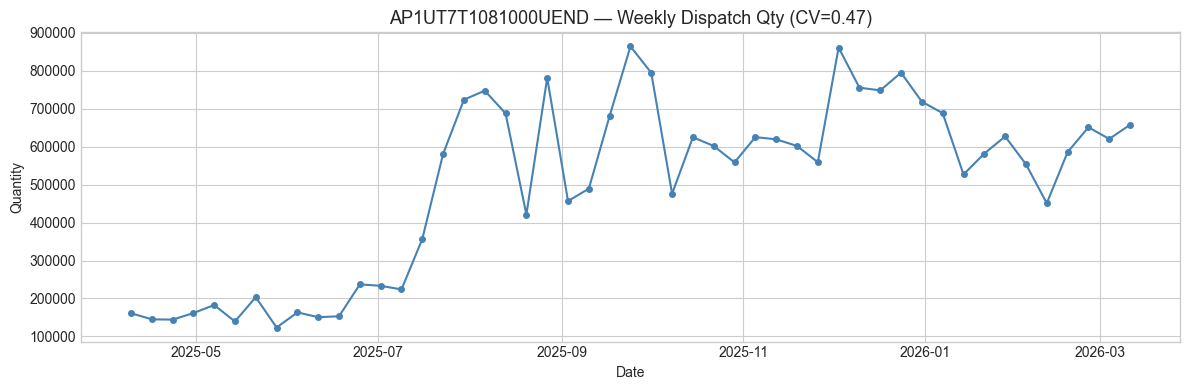

In [3]:
# Pick the most volatile SKU
CHOSEN_SKU = stats.index[0][0]
CHOSEN_NAME = stats.index[0][1]
CHOSEN_UNIT = stats.index[0][2]
print(f"Selected: {CHOSEN_SKU}")
print(f"Name:     {CHOSEN_NAME}")
print(f"Unit:     {CHOSEN_UNIT}")
print(f"CV:       {stats.iloc[0]['cv']:.3f}")

sku_df = df[df["sku"] == CHOSEN_SKU].sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sku_df["date"], sku_df["qty"], "o-", color="steelblue", markersize=4)
ax.set_title(f"{CHOSEN_SKU} — Weekly Dispatch Qty (CV={stats.iloc[0]['cv']:.2f})", fontsize=13)
ax.set_ylabel("Quantity")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

## 2. Chronos-2 Baseline

Split into **context** (first N-8 weeks) and **ground truth** (last 8 weeks).

We run Chronos-2 two ways and compare:
- **Standalone** — directly via the `chronos-forecasting` package's [predict_df](cci:1://file:///opt/miniconda3/envs/tft_forecasting/lib/python3.10/site-packages/chronos/chronos2/pipeline.py:814:4-940:29) API
- **Migas-internal** — extracted from Migas 1.5 with `return_univariate=True`

In [4]:
PRED_LEN = 8

# Prepare Migas-format DataFrame (columns: t, y_t)
migas_df = sku_df[["date", "qty"]].rename(columns={"date": "t", "qty": "y_t"})
migas_df["t"] = migas_df["t"].dt.strftime("%Y-%m-%d")

ctx_df = migas_df.iloc[:-PRED_LEN].reset_index(drop=True)  # context window
gt = migas_df.iloc[-PRED_LEN:]["y_t"].values                # ground truth

print(f"Context:  {len(ctx_df)} steps  ({ctx_df['t'].iloc[0]} → {ctx_df['t'].iloc[-1]})")
print(f"Forecast: {PRED_LEN} steps ({migas_df['t'].iloc[-PRED_LEN]} → {migas_df['t'].iloc[-1]})")

Context:  41 steps  (2025-04-09 → 2026-01-14)
Forecast: 8 steps (2026-01-21 → 2026-03-11)


In [5]:
# Load Migas-1.5 pipeline (also loads Chronos-2 internally)
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device="cpu")
print("Migas pipeline loaded.")

# Load standalone Chronos-2 pipeline
chronos_pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2", device_map="cpu", dtype=torch.float32
)
print("Standalone Chronos-2 loaded.")

Loading Chronos-2 on device: cpu
Initialized univariate model: chronos
Migas pipeline loaded.
Standalone Chronos-2 loaded.


In [6]:
# --- 2a. Standalone Chronos-2 via predict_df ---
timestamps = pd.date_range(start="2025-01-01", periods=len(ctx_df), freq="W")
chronos_input_df = pd.DataFrame({
    "item_id": "sku_0",
    "timestamp": timestamps,
    "target": ctx_df["y_t"].values.astype(np.float64),
})

pred_df = chronos_pipeline.predict_df(
    chronos_input_df,
    id_column="item_id",
    timestamp_column="timestamp",
    target="target",
    prediction_length=PRED_LEN,
    quantile_levels=[0.1, 0.5, 0.9],
)
fc_chronos_standalone = pred_df["predictions"].values

# --- 2b. Migas-internal Chronos-2 via return_univariate ---
neutral_summary = (
    "FACTUAL SUMMARY:\n"
    "The series shows typical weekly fluctuations in dispatch volumes.\n\n"
    "PREDICTIVE SIGNALS:\n"
    "No strong directional signals. Expect continuation of recent patterns."
)

fc_neutral, fc_chronos_migas = pipeline.predict_from_dataframe(
    ctx_df, pred_len=PRED_LEN, summaries=neutral_summary, return_univariate=True
)

# --- Compare ---
mae_between = np.mean(np.abs(fc_chronos_standalone - fc_chronos_migas))
print(f"Standalone Chronos-2:      {fc_chronos_standalone[:4].round(0)}")
print(f"Migas-internal Chronos-2:  {fc_chronos_migas[:4].round(0)}")
print(f"MAE between them:          {mae_between:,.0f}")

Standalone Chronos-2:      [572526. 553351. 521419. 478030.]
Migas-internal Chronos-2:  [572526. 553351. 521419. 478030.]
MAE between them:          0


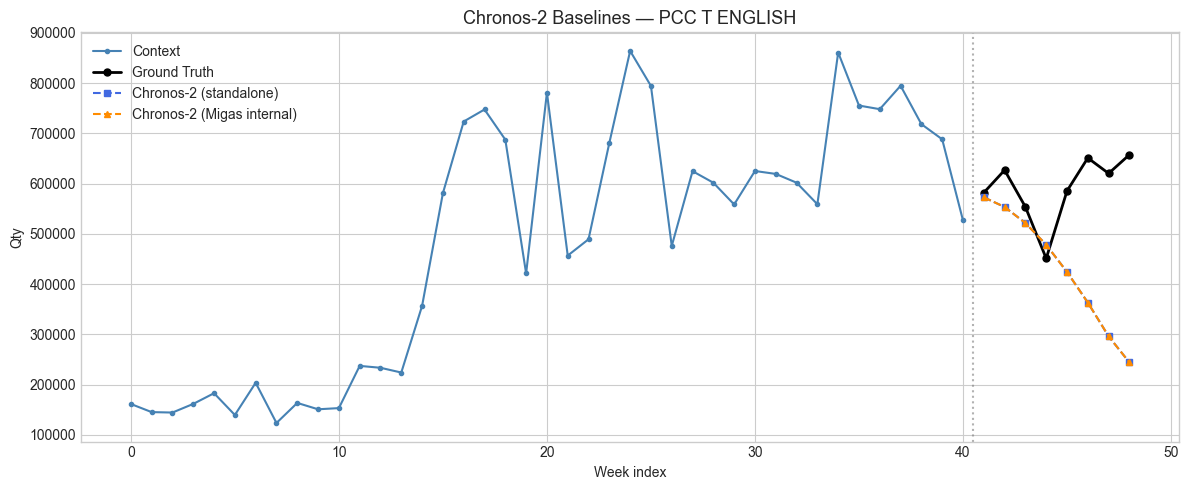

Standalone Chronos-2           MAE=   166,046   RMSE=   221,372
Migas-internal Chronos-2       MAE=   166,046   RMSE=   221,372


In [7]:
t_ctx = range(len(ctx_df))
t_fc = range(len(ctx_df), len(ctx_df) + PRED_LEN)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_ctx, ctx_df["y_t"].values, "o-", color="steelblue", ms=3, label="Context")
ax.plot(t_fc, gt, "o-", color="black", ms=5, lw=2, label="Ground Truth")
ax.plot(t_fc, fc_chronos_standalone, "s--", color="royalblue", ms=5, label="Chronos-2 (standalone)")
ax.plot(t_fc, fc_chronos_migas, "^--", color="darkorange", ms=5, label="Chronos-2 (Migas internal)")
ax.axvline(len(ctx_df) - 0.5, color="gray", ls=":", alpha=0.6)
ax.legend()
ax.set_title(f"Chronos-2 Baselines — {CHOSEN_NAME}", fontsize=13)
ax.set_ylabel("Qty")
ax.set_xlabel("Week index")
plt.tight_layout()
plt.show()

# Quick metrics
for label, fc in [("Standalone Chronos-2", fc_chronos_standalone),
                  ("Migas-internal Chronos-2", fc_chronos_migas)]:
    mae = np.mean(np.abs(gt - fc))
    rmse = np.sqrt(np.mean((gt - fc) ** 2))
    print(f"{label:<30} MAE={mae:>10,.0f}   RMSE={rmse:>10,.0f}")

## 3. Migas 1.5 — Precomputed Summaries

Test how different narratives steer the forecast.  
All scenarios share the same **FACTUAL SUMMARY** but differ in **PREDICTIVE SIGNALS**:

- **Bullish** — demand expected to surge
- **Bearish** — demand expected to decline
- **Neutral** — no strong signals

In [30]:
# Shared factual summary based on the actual data
factual = (
    "FACTUAL SUMMARY:\n"
    f"Weekly cement dispatch for {CHOSEN_NAME} ({CHOSEN_UNIT}) ranged from "
    f"{ctx_df['y_t'].min():.0f} to {ctx_df['y_t'].max():.0f} units over "
    f"{len(ctx_df)} weeks ({ctx_df['t'].iloc[0]} to {ctx_df['t'].iloc[-1]}). "
    f"Mean dispatch was {ctx_df['y_t'].mean():.0f} with std {ctx_df['y_t'].std():.0f}. "
    f"Recent 4-week average: {ctx_df['y_t'].iloc[-4:].mean():.0f}."
)

scenarios = {
    "Bullish": (
        f"{factual}\n\n"
        "PREDICTIVE SIGNALS:\n"
        "Strong construction demand surge expected. Infrastructure spending accelerating, "
        "monsoon season ending boosts activity. Dispatch volumes likely to increase significantly "
        "with substantial upward fluctuations well above recent averages in coming weeks. "
        "Project a sharp 30-50% increase from current levels."
    ),
    "Bearish": (
        f"{factual}\n\n"
        "PREDICTIVE SIGNALS:\n"
        "Demand destruction ahead. Monsoon intensification, labor shortages, and input cost "
        "inflation expected to depress dispatch volumes significantly. Likely sharp decline of 30-50% from "
        "recent levels over the forecast horizon with continued downward pressure."
    ),
    "Neutral": neutral_summary,
}

# Run forecasts for each scenario
forecasts = {
    "Chronos-2 (standalone)": fc_chronos_standalone,
    "Chronos-2 (Migas internal)": fc_chronos_migas,
}
for name, summary in scenarios.items():
    fc = pipeline.predict_from_dataframe(ctx_df, pred_len=PRED_LEN, summaries=summary)
    forecasts[f"Migas ({name})"] = fc
    print(f"{name:>10}: {fc[:4].round(0)} ...")

   Bullish: [578481. 564226. 543084. 504822.] ...
   Bearish: [578544. 564178. 545044. 506369.] ...
   Neutral: [456954. 576128. 631893. 574862.] ...


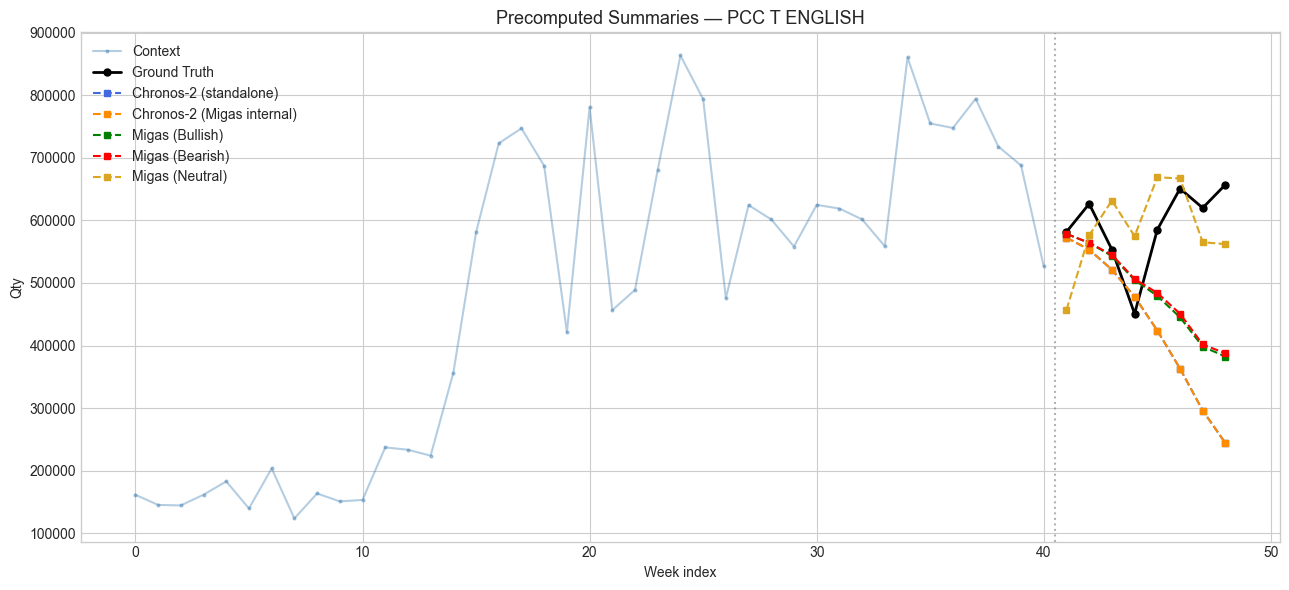

In [31]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(t_ctx, ctx_df["y_t"].values, "o-", color="steelblue", ms=2, alpha=0.4, label="Context")
ax.plot(t_fc, gt, "o-", color="black", ms=5, lw=2, label="Ground Truth")

colors = {
    "Chronos-2 (standalone)": "royalblue",
    "Chronos-2 (Migas internal)": "darkorange",
    "Migas (Bullish)": "green",
    "Migas (Bearish)": "red",
    "Migas (Neutral)": "goldenrod",
}
for name, fc in forecasts.items():
    ax.plot(t_fc, fc, "s--", color=colors[name], ms=4, label=name)

ax.axvline(len(ctx_df) - 0.5, color="gray", ls=":", alpha=0.6)
ax.legend(loc="upper left")
ax.set_title(f"Precomputed Summaries — {CHOSEN_NAME}", fontsize=13)
ax.set_ylabel("Qty")
ax.set_xlabel("Week index")
plt.tight_layout()
plt.show()

In [35]:
# Add this NEW cell after Cell 11 to inspect convex weights
import torch

# Get model internals
test_summaries = [scenarios["Bullish"], scenarios["Bearish"]]
context_batch = np.tile(ctx_df["y_t"].values.reshape(1, -1), (2, 1))

with torch.no_grad():
    # Normalize context
    ctx_tensor = torch.tensor(context_batch, dtype=torch.float32).unsqueeze(-1)
    mu = ctx_tensor.mean(dim=1, keepdim=True)
    sigma = ctx_tensor.std(dim=1, keepdim=True)
    ctx_normed = (ctx_tensor - mu) / (sigma + 1e-8)
    
    # Get the fused embeddings
    out = pipeline.model(
        ctx_normed,
        text=None,
        pred_len=PRED_LEN,
        history_mean=mu.squeeze(),
        history_std=sigma.squeeze(),
        summaries=test_summaries,
        training=False
    )
    
    # Extract convex weights if available
    if hasattr(pipeline.model, 'convex_weight_net'):
        # Recompute to get weights
        print("Convex combination is enabled")
        print("If weights are ~1.0, text signals are being ignored")

print("\nBullish summary:")
print(scenarios["Bullish"])
print("\nBearish summary:")
print(scenarios["Bearish"])

Convex combination is enabled
If weights are ~1.0, text signals are being ignored

Bullish summary:
FACTUAL SUMMARY:
Weekly cement dispatch for PCC T ENGLISH (ANDHRA PRADESH CEMENT WORKS) ranged from 123516 to 863822 units over 41 weeks (2025-04-09 to 2026-01-14). Mean dispatch was 481963 with std 250654. Recent 4-week average: 681794.

PREDICTIVE SIGNALS:
Strong construction demand surge expected. Infrastructure spending accelerating, monsoon season ending boosts activity. Dispatch volumes likely to increase significantly with substantial upward fluctuations well above recent averages in coming weeks. Project a sharp 30-50% increase from current levels.

Bearish summary:
FACTUAL SUMMARY:
Weekly cement dispatch for PCC T ENGLISH (ANDHRA PRADESH CEMENT WORKS) ranged from 123516 to 863822 units over 41 weeks (2025-04-09 to 2026-01-14). Mean dispatch was 481963 with std 250654. Recent 4-week average: 681794.

PREDICTIVE SIGNALS:
Demand destruction ahead. Monsoon intensification, labor sho

## 4. Migas 1.5 — LLM-Generated Summaries

Use **OpenAI** to automatically generate FACTUAL SUMMARY + PREDICTIVE SIGNALS  
based on the time series data. Reads `OPENAI_API_KEY` from `.env` file.

This generates multiple summaries (ensemble) for more stable forecasts.

In [38]:
api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    print("Set OPENAI_API_KEY in .env to run this section. Skipping.")
else:
    llm_summaries = generate_summary(
        series_name=f"{CHOSEN_NAME} ({CHOSEN_UNIT}) — Weekly Cement Dispatch",
        series=ctx_df,
        pred_len=PRED_LEN,
        llm_provider="openai",
        llm_api_key=api_key,
        n_summaries=3,
    )

    fc_llm = pipeline.predict_from_dataframe(
        ctx_df, pred_len=PRED_LEN, summaries=llm_summaries
    )
    forecasts["Migas (LLM)"] = fc_llm
    print(f"\nLLM ensemble forecast (first 4): {fc_llm[:4].round(0)}")

Calling openai to generate summary (price data only) …
Generating 3 summary(ies) …
  Generated summary 1/3
  Generated summary 2/3
  Generated summary 3/3

Generated 3 summary(ies):

**FACTUAL SUMMARY:**  
The historical data from April 2025 to January 2026 reveals significant volatility in values, with a notable upward trend from mid-July 2025 onwards. Starting at 161,328 on April 9, the values fluctuated with a low of 123,516 on May 28 before surging dramatically to 723,398 by July 30. The peak occurred on September 24, reaching 863,822, followed by a gradual decline towards the end of the year, stabilizing around 718,144 by December 31. The overall range of values spanned from a low of 123,516 to a high of 863,822, indicating a remarkable increase of approximately 600% at its peak. This period was characterized by sharp increases, particularly between July and September, suggesting potential catalysts such as market demand shifts or external economic factors influencing investor beh

## 5. Final Comparison

In [39]:
# Metrics: MAE and RMSE for each model
print(f"{'Model':<25} {'MAE':>12} {'RMSE':>12}")
print("-" * 50)
for name, fc in forecasts.items():
    mae = np.mean(np.abs(gt - fc))
    rmse = np.sqrt(np.mean((gt - fc) ** 2))
    print(f"{name:<25} {mae:>12,.0f} {rmse:>12,.0f}")

Model                              MAE         RMSE
--------------------------------------------------
Chronos-2 (standalone)         166,046      221,372
Chronos-2 (Migas internal)      166,046      221,372
Migas (Bullish)                117,318      152,198
Migas (Bearish)                114,888      149,097
Migas (Neutral)                 78,481       85,882
Migas (LLM)                    134,354      177,837


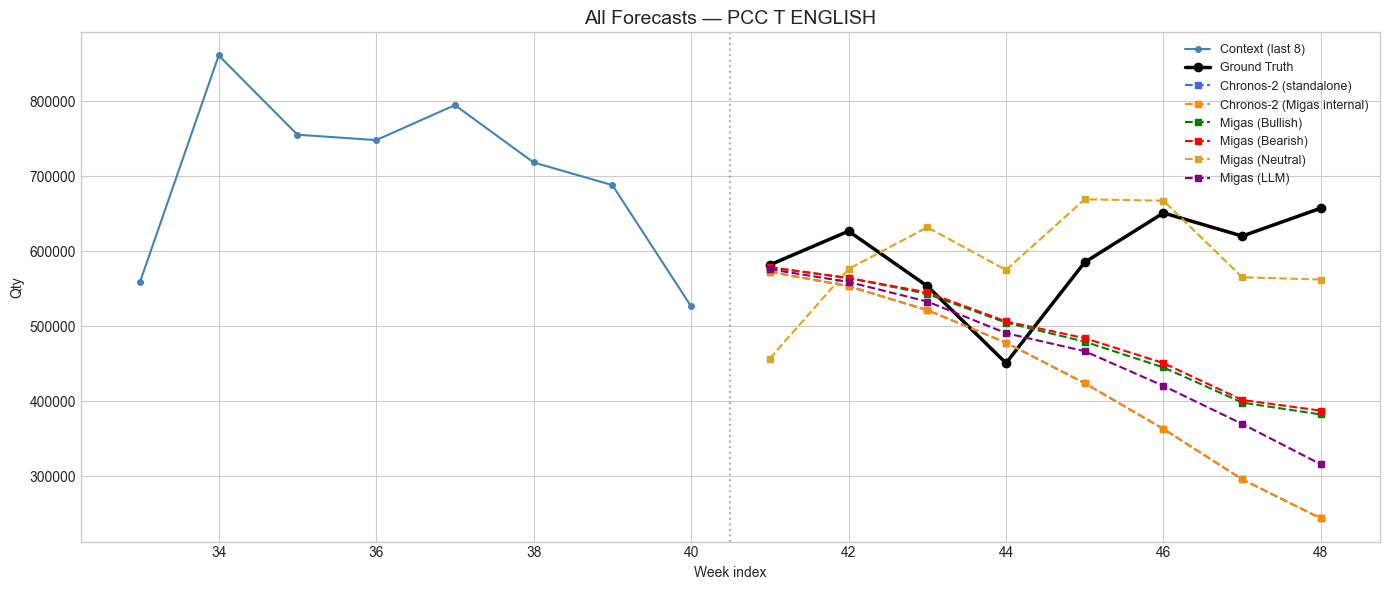

In [40]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t_ctx[-8:], ctx_df["y_t"].values[-8:], "o-", color="steelblue", ms=4, label="Context (last 8)")
ax.plot(t_fc, gt, "o-", color="black", ms=6, lw=2.5, label="Ground Truth")

all_colors = {
    "Chronos-2 (standalone)": "royalblue",
    "Chronos-2 (Migas internal)": "darkorange",
    "Migas (Bullish)": "green",
    "Migas (Bearish)": "red",
    "Migas (Neutral)": "goldenrod",
    "Migas (LLM)": "purple",
}
for name, fc in forecasts.items():
    ax.plot(t_fc, fc, "s--", color=all_colors.get(name, "gray"), ms=5, label=name)

ax.axvline(len(ctx_df) - 0.5, color="gray", ls=":", alpha=0.6)
ax.legend(loc="best", fontsize=9)
ax.set_title(f"All Forecasts — {CHOSEN_NAME}", fontsize=14)
ax.set_ylabel("Qty")
ax.set_xlabel("Week index")
plt.tight_layout()
plt.show()